# **Important! I reran the codes so the results are slightly different as one of the stock was delisted and I changed it to another stock**

# *Model Comparison Strategy*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\tyxeu\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\tyxeu\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\tyxeu\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\tyxeu\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\tyxeu\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\tyxeu\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\tyxeu\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\tyxeu\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


Loading saved data and models...
 Random Forest model loaded
 Feature columns loaded (29 features)
 Feature importances loaded
 Test data loaded (224 samples)
 Latest master features loaded (55 stocks)
 Stock universe loaded (55 stocks)
 Fundamentals data loaded

 All data loaded successfully!

Defining Factor Scoring Model...
 Factor scoring function defined

Generating recommendations on latest data...
 Scored 55 stocks
  Factor Score range: 27.06 - 70.08
  ML Probability range: 0.122 - 0.685

Identifying top recommendations...

Factor Model Top 5: ['AJBU.SI', 'BS6.SI', 'D05.SI', 'O39.SI', 'S68.SI']
ML Model Top 5:     ['1D0.SI', '42R.SI', 'BS6.SI', 'QC7.SI', 'U77.SI']

Factor Model Top 10: ['AIY.SI', 'AJBU.SI', 'BS6.SI', 'D05.SI', 'O39.SI', 'OV8.SI', 'S68.SI', 'U10.SI', 'U11.SI', 'Z74.SI']
ML Model Top 10:     ['1D0.SI', '42R.SI', '546.SI', '5OI.SI', '9CI.SI', 'BS6.SI', 'P34.SI', 'QC7.SI', 'U77.SI', 'Y92.SI']

Calculating model agreement and confidence levels...

 HIGH Confidence (

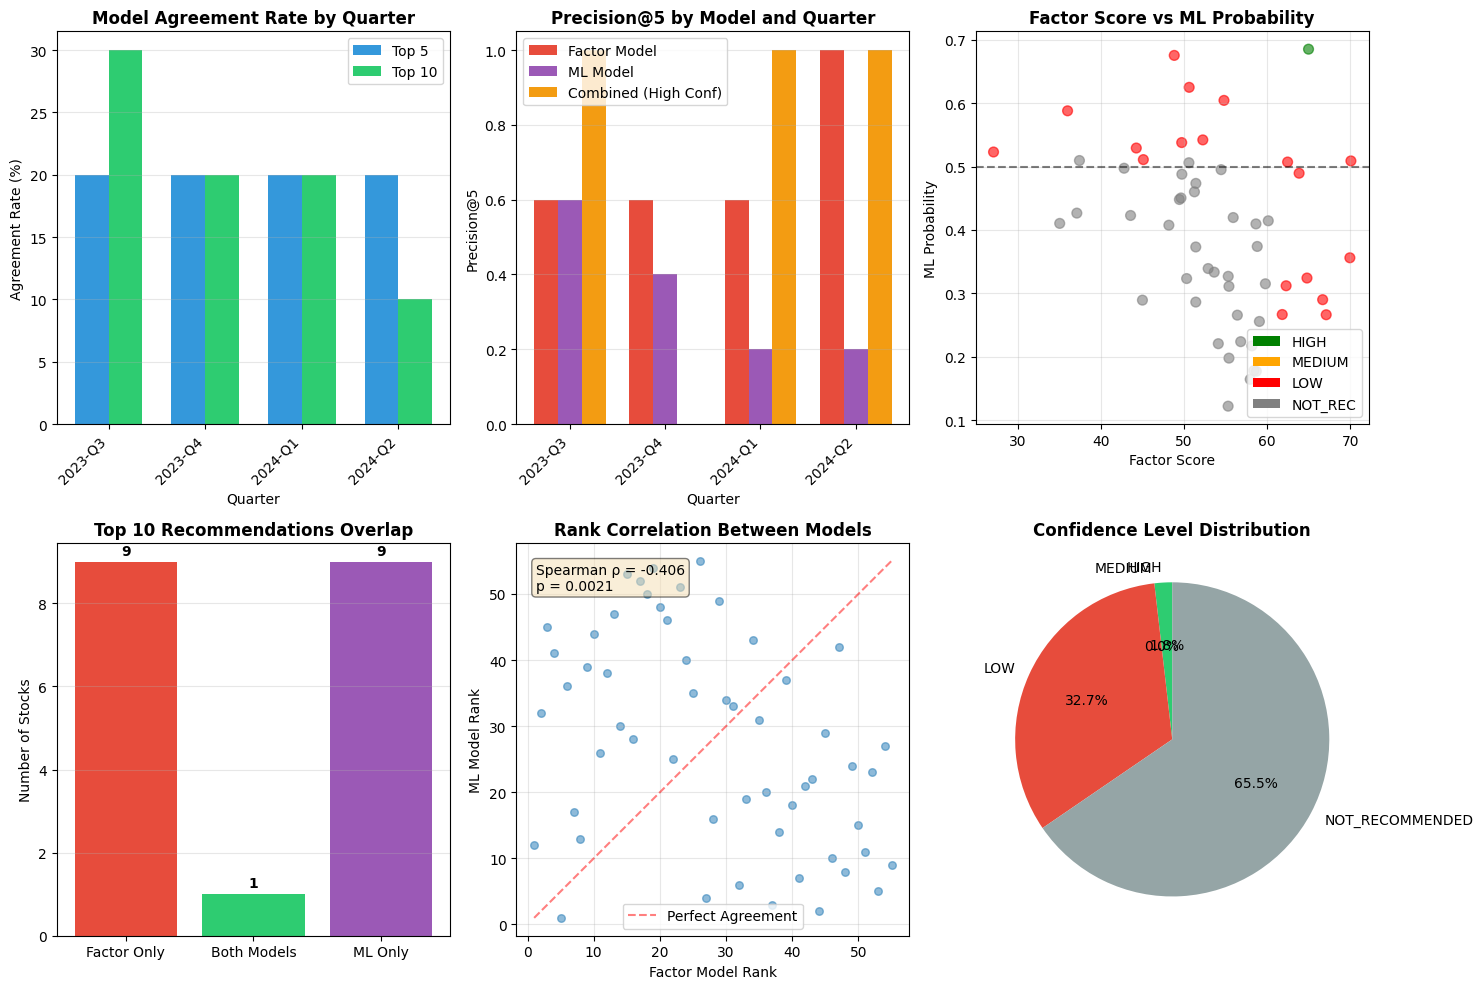

 Visualization saved to: data/ml/model_comparison.png

Analyzing unique recommendations from each model...

 Stocks ONLY recommended by Factor Model (not in ML Top 10):
------------------------------------------------------------
 Ticker                 Sector  Factor_Rank  Factor_Score  ML_Rank  ML_Probability
 D05.SI     Financial Services            1     70.083599       12        0.508841
 S68.SI     Financial Services            2     69.959169       32        0.356220
AJBU.SI            Real Estate            3     67.109481       45        0.266500
 O39.SI     Financial Services            4     66.681899       41        0.290249
 U11.SI     Financial Services            6     64.794426       36        0.324334
 AIY.SI             Technology            7     63.848212       17        0.489458
 Z74.SI Communication Services            8     62.461733       13        0.507090
 OV8.SI     Consumer Defensive            9     62.285067       39        0.312163
 U10.SI     Financial S

In [2]:
# LOAD ALL REQUIRED DATA AND MODELS
print("\nLoading saved data and models...")

# Load the trained Random Forest model
rf_model = joblib.load('data/ml/rf_model.joblib')
print(" Random Forest model loaded")

# Load feature columns
feature_cols = pd.read_csv('data/ml/feature_columns.csv')['Feature'].tolist()
print(f" Feature columns loaded ({len(feature_cols)} features)")

# Load feature importances
feature_importance = pd.read_csv('data/ml/feature_importance.csv')
print(" Feature importances loaded")

# Load test data (for multi-period analysis)
test_df = pd.read_csv('data/ml/test_data.csv', parse_dates=['Snapshot_Date'])
print(f" Test data loaded ({len(test_df)} samples)")

# Load the latest master features (for current recommendations)
master_df = pd.read_csv('data/master_features_latest.csv')
print(f" Latest master features loaded ({len(master_df)} stocks)")

# Load stock universe for company names
stock_universe = pd.read_csv('data/stock_universe_clean.csv')
print(f" Stock universe loaded ({len(stock_universe)} stocks)")

# Load fundamentals for additional info
fundamentals = pd.read_csv('data/fundamentals_clean.csv')
print(" Fundamentals data loaded")

print("\n All data loaded successfully!")

# DEFINE FACTOR SCORING FUNCTION
print("\nDefining Factor Scoring Model...")

def compute_factor_score(row):
    """
    Factor-based scoring model as per FYP system design.
    
    Formula:
    Sᵢ = 0.20·rev_growth + 0.10·eps_growth + 0.10·momentum 
       + 0.15·roe + 0.10·margin + 0.10·low_debt + 0.05·mcap 
       + 0.10·low_vol + 0.10·low_drawdown
    
    Total weights: 100%
    """
    score = 0
    
    # GROWTH FACTORS (40%)
    # Revenue Growth (20%)
    if pd.notna(row.get('Revenue_Growth')):
        rev_growth = np.clip(row['Revenue_Growth'], -0.5, 1.0)
        rev_growth_normalized = (rev_growth + 0.5) / 1.5 * 100
        score += rev_growth_normalized * 0.20
    
    # EPS Growth (10%)
    if pd.notna(row.get('EPS')):
        eps_normalized = np.clip(row['EPS'], -1, 5)
        eps_score = (eps_normalized + 1) / 6 * 100
        score += eps_score * 0.10
    
    # Momentum (10%)
    if pd.notna(row.get('Return_6M')):
        momentum = np.clip(row['Return_6M'], -0.5, 1.0)
        momentum_normalized = (momentum + 0.5) / 1.5 * 100
        score += momentum_normalized * 0.10
    
    # QUALITY FACTORS (40%)
    # ROE (15%)
    if pd.notna(row.get('ROE')):
        roe = np.clip(row['ROE'], -0.2, 0.4)
        roe_normalized = (roe + 0.2) / 0.6 * 100
        score += roe_normalized * 0.15
    
    # Profit Margin (10%)
    if pd.notna(row.get('Profit_Margin')):
        margin = np.clip(row['Profit_Margin'], -0.2, 0.5)
        margin_normalized = (margin + 0.2) / 0.7 * 100
        score += margin_normalized * 0.10
    
    # Low Debt-to-Equity (10%)
    if pd.notna(row.get('Debt_to_Equity')):
        debt = np.clip(row['Debt_to_Equity'], 0, 300)
        low_debt_normalized = (300 - debt) / 300 * 100
        score += low_debt_normalized * 0.10
    
    # Market Cap (5%)
    if pd.notna(row.get('Market_Cap')):
        mcap_log = np.log10(max(row['Market_Cap'], 1e6))
        mcap_normalized = np.clip((mcap_log - 6) / 5.2 * 100, 0, 100)
        score += mcap_normalized * 0.05
    
    # RISK FACTORS (20%)
    # Low Volatility (10%)
    if pd.notna(row.get('Volatility')) and row['Volatility'] > 0:
        vol = np.clip(row['Volatility'], 0.1, 0.8)
        low_vol_normalized = (0.8 - vol) / 0.7 * 100
        score += low_vol_normalized * 0.10
    
    # Low Max Drawdown (10%)
    if pd.notna(row.get('Max_Drawdown')):
        drawdown = np.clip(row['Max_Drawdown'], -0.6, 0)
        low_drawdown_normalized = (drawdown + 0.6) / 0.6 * 100
        score += low_drawdown_normalized * 0.10
    
    return score

print(" Factor scoring function defined")

# GENERATE RECOMMENDATIONS ON LATEST DATA
print("\nGenerating recommendations on latest data...")
print("="*60)

# Create a copy for analysis
latest_df = master_df.copy()

# Compute Factor Scores
latest_df['Factor_Score'] = latest_df.apply(compute_factor_score, axis=1)

# Add sector one-hot encoding to match training feature set
sector_dummies = pd.get_dummies(latest_df['Sector'], prefix='Sector')
latest_df = pd.concat([latest_df, sector_dummies], axis=1)
for col in feature_cols:
    if col.startswith('Sector_') and col not in latest_df.columns:
        latest_df[col] = 0


# Prepare features for ML model
X_latest = latest_df[feature_cols].copy()

# Fill missing values with median
train_medians = X_latest.median()
X_latest = X_latest.fillna(train_medians)

# Get ML Predictions (probabilities)
latest_df['ML_Probability'] = rf_model.predict_proba(X_latest)[:, 1]
latest_df['ML_Prediction'] = rf_model.predict(X_latest)

# Rank stocks by each model
latest_df['Factor_Rank'] = latest_df['Factor_Score'].rank(ascending=False, method='min').astype(int)
latest_df['ML_Rank'] = latest_df['ML_Probability'].rank(ascending=False, method='min').astype(int)

print(f" Scored {len(latest_df)} stocks")
print(f"  Factor Score range: {latest_df['Factor_Score'].min():.2f} - {latest_df['Factor_Score'].max():.2f}")
print(f"  ML Probability range: {latest_df['ML_Probability'].min():.3f} - {latest_df['ML_Probability'].max():.3f}")

# IDENTIFY TOP RECOMMENDATIONS
print("\nIdentifying top recommendations...")
print("="*60)

# Top N configurations
TOP_5 = 5
TOP_10 = 10

# Get top stocks from each model
top5_factor = set(latest_df.nsmallest(TOP_5, 'Factor_Rank')['Ticker'].values)
top10_factor = set(latest_df.nsmallest(TOP_10, 'Factor_Rank')['Ticker'].values)

top5_ml = set(latest_df.nsmallest(TOP_5, 'ML_Rank')['Ticker'].values)
top10_ml = set(latest_df.nsmallest(TOP_10, 'ML_Rank')['Ticker'].values)

print(f"\nFactor Model Top 5: {sorted(top5_factor)}")
print(f"ML Model Top 5:     {sorted(top5_ml)}")

print(f"\nFactor Model Top 10: {sorted(top10_factor)}")
print(f"ML Model Top 10:     {sorted(top10_ml)}")

# CALCULATE AGREEMENT AND CONFIDENCE
print("\nCalculating model agreement and confidence levels...")
print("="*60)

# Agreement analysis
high_confidence = top5_factor & top5_ml  # In top 5 of BOTH
medium_confidence = (top10_factor & top10_ml) - high_confidence  # In top 10 of both, but not top 5 of both
factor_only = top10_factor - top10_ml  # Only in Factor top 10
ml_only = top10_ml - top10_factor  # Only in ML top 10

print(f"\n HIGH Confidence (Top 5 of BOTH models):")
print(f"   Stocks: {sorted(high_confidence) if high_confidence else 'None'}")
print(f"   Count: {len(high_confidence)}")

print(f"\n MEDIUM Confidence (Top 10 of BOTH, not both Top 5):")
print(f"   Stocks: {sorted(medium_confidence) if medium_confidence else 'None'}")
print(f"   Count: {len(medium_confidence)}")

print(f"\n Factor Model Only (Top 10):")
print(f"   Stocks: {sorted(factor_only) if factor_only else 'None'}")
print(f"   Count: {len(factor_only)}")

print(f"\n ML Model Only (Top 10):")
print(f"   Stocks: {sorted(ml_only) if ml_only else 'None'}")
print(f"   Count: {len(ml_only)}")

# Agreement rates
agreement_top5 = len(top5_factor & top5_ml) / TOP_5 * 100
agreement_top10 = len(top10_factor & top10_ml) / TOP_10 * 100

print(f"\n Agreement Rates:")
print(f"   Top 5 Agreement:  {len(top5_factor & top5_ml)}/{TOP_5} ({agreement_top5:.1f}%)")
print(f"   Top 10 Agreement: {len(top10_factor & top10_ml)}/{TOP_10} ({agreement_top10:.1f}%)")

# ASSIGN CONFIDENCE LEVELS TO ALL STOCKS
print("\nAssigning confidence levels to stocks...")

def assign_confidence(row):
    """Assign confidence level based on model agreement."""
    ticker = row['Ticker']
    
    if ticker in high_confidence:
        return 'HIGH'
    elif ticker in medium_confidence:
        return 'MEDIUM'
    elif ticker in top10_factor or ticker in top10_ml:
        return 'LOW'
    else:
        return 'NOT_RECOMMENDED'

latest_df['Confidence'] = latest_df.apply(assign_confidence, axis=1)

# Create combined score for ranking (normalized Factor + ML)
latest_df['Factor_Score_Norm'] = (latest_df['Factor_Score'] - latest_df['Factor_Score'].min()) / \
                                  (latest_df['Factor_Score'].max() - latest_df['Factor_Score'].min())
latest_df['Combined_Score'] = (latest_df['Factor_Score_Norm'] + latest_df['ML_Probability']) / 2

print(" Confidence levels assigned")

# CREATE RECOMMENDATION TABLE
print("\nCreating recommendation table...")
print("="*60)

# Get all recommended stocks (in top 10 of either model)
all_recommended = top10_factor | top10_ml
recommended_df = latest_df[latest_df['Ticker'].isin(all_recommended)].copy()

# Add company names
recommended_df = recommended_df.merge(
    stock_universe[['Ticker', 'Company_Name']], 
    on='Ticker', 
    how='left'
)

# Sort by confidence level, then combined score
confidence_order = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
recommended_df['Confidence_Order'] = recommended_df['Confidence'].map(confidence_order)
recommended_df = recommended_df.sort_values(['Confidence_Order', 'Combined_Score'], ascending=[True, False])

# Display recommendation table
print("\n" + "="*80)
print(" STOCK RECOMMENDATIONS - LATEST DATA")
print("="*80)

display_cols = ['Ticker', 'Company_Name', 'Sector', 'Confidence', 
                'Factor_Rank', 'ML_Rank', 'Factor_Score', 'ML_Probability']

print("\n HIGH CONFIDENCE (Both models strongly agree):")
print("-"*80)
high_df = recommended_df[recommended_df['Confidence'] == 'HIGH'][display_cols]
if len(high_df) > 0:
    print(high_df.to_string(index=False))
else:
    print("  No stocks in HIGH confidence category")

print("\n MEDIUM CONFIDENCE (Both models agree):")
print("-"*80)
medium_df = recommended_df[recommended_df['Confidence'] == 'MEDIUM'][display_cols]
if len(medium_df) > 0:
    print(medium_df.to_string(index=False))
else:
    print("  No stocks in MEDIUM confidence category")

print("\n LOW CONFIDENCE (Only one model recommends):")
print("-"*80)
low_df = recommended_df[recommended_df['Confidence'] == 'LOW'][display_cols]
if len(low_df) > 0:
    print(low_df.to_string(index=False))
else:
    print("  No stocks in LOW confidence category")

# ANALYZE AGREEMENT ACROSS TEST PERIODS
print("\nAnalyzing agreement across test periods...")
print("="*60)

# Get unique quarters in test data
test_quarters = test_df['Quarter'].unique()
print(f"\nTest periods: {sorted(test_quarters)}")

# Analyze agreement per quarter
period_analysis = []

for quarter in sorted(test_quarters):
    quarter_data = test_df[test_df['Quarter'] == quarter].copy()
    
    # Compute Factor Scores for this period
    quarter_data['Factor_Score'] = quarter_data.apply(compute_factor_score, axis=1)

    # Add sector one-hot encoding to match training feature set
    sector_dummies_q = pd.get_dummies(quarter_data['Sector'], prefix='Sector')
    quarter_data = pd.concat([quarter_data, sector_dummies_q], axis=1)
    for col in feature_cols:
        if col.startswith('Sector_') and col not in quarter_data.columns:
            quarter_data[col] = 0

    
    # Get ML Probabilities
    X_quarter = quarter_data[feature_cols].fillna(train_medians)
    quarter_data['ML_Probability'] = rf_model.predict_proba(X_quarter)[:, 1]
    
    # Get top stocks from each model
    quarter_top5_factor = set(quarter_data.nlargest(TOP_5, 'Factor_Score')['Ticker'].values)
    quarter_top5_ml = set(quarter_data.nlargest(TOP_5, 'ML_Probability')['Ticker'].values)
    quarter_top10_factor = set(quarter_data.nlargest(TOP_10, 'Factor_Score')['Ticker'].values)
    quarter_top10_ml = set(quarter_data.nlargest(TOP_10, 'ML_Probability')['Ticker'].values)
    
    # Calculate agreement
    overlap_5 = len(quarter_top5_factor & quarter_top5_ml)
    overlap_10 = len(quarter_top10_factor & quarter_top10_ml)
    
    # Get actual outperformers (Label = 1)
    actual_outperformers = set(quarter_data[quarter_data['Label'] == 1]['Ticker'].values)
    
    # Calculate precision (how many recommendations were actual outperformers)
    factor_precision_5 = len(quarter_top5_factor & actual_outperformers) / TOP_5 if TOP_5 > 0 else 0
    ml_precision_5 = len(quarter_top5_ml & actual_outperformers) / TOP_5 if TOP_5 > 0 else 0
    combined_top5 = quarter_top5_factor & quarter_top5_ml
    combined_precision_5 = len(combined_top5 & actual_outperformers) / len(combined_top5) if len(combined_top5) > 0 else 0
    
    period_analysis.append({
        'Quarter': quarter,
        'Total_Stocks': len(quarter_data),
        'Actual_Outperformers': len(actual_outperformers),
        'Top5_Overlap': overlap_5,
        'Top5_Agreement%': overlap_5 / TOP_5 * 100,
        'Top10_Overlap': overlap_10,
        'Top10_Agreement%': overlap_10 / TOP_10 * 100,
        'Factor_Precision@5': factor_precision_5,
        'ML_Precision@5': ml_precision_5,
        'Combined_Precision@5': combined_precision_5
    })

# Create analysis DataFrame
period_df = pd.DataFrame(period_analysis)

print("\nAgreement Analysis by Quarter:")
print("-"*80)
print(period_df.to_string(index=False))

# Summary statistics
print("\n" + "-"*80)
print("Summary Statistics:")
print(f"  Mean Top 5 Agreement:  {period_df['Top5_Agreement%'].mean():.1f}%")
print(f"  Mean Top 10 Agreement: {period_df['Top10_Agreement%'].mean():.1f}%")
print(f"  Mean Factor Precision@5: {period_df['Factor_Precision@5'].mean():.2f}")
print(f"  Mean ML Precision@5:     {period_df['ML_Precision@5'].mean():.2f}")
print(f"  Mean Combined Precision@5: {period_df['Combined_Precision@5'].mean():.2f}")

# VISUALIZE MODEL COMPARISON
print("\nCreating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Agreement Rates by Quarter
ax1 = axes[0, 0]
x = range(len(period_df))
width = 0.35
ax1.bar([i - width/2 for i in x], period_df['Top5_Agreement%'], width, label='Top 5', color='#3498db')
ax1.bar([i + width/2 for i in x], period_df['Top10_Agreement%'], width, label='Top 10', color='#2ecc71')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Agreement Rate (%)')
ax1.set_title('Model Agreement Rate by Quarter', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(period_df['Quarter'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Precision Comparison
ax2 = axes[0, 1]
x = range(len(period_df))
width = 0.25
ax2.bar([i - width for i in x], period_df['Factor_Precision@5'], width, label='Factor Model', color='#e74c3c')
ax2.bar([i for i in x], period_df['ML_Precision@5'], width, label='ML Model', color='#9b59b6')
ax2.bar([i + width for i in x], period_df['Combined_Precision@5'], width, label='Combined (High Conf)', color='#f39c12')
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Precision@5')
ax2.set_title('Precision@5 by Model and Quarter', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(period_df['Quarter'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Factor Score vs ML Probability (Latest Data)
ax3 = axes[0, 2]
colors = latest_df['Confidence'].map({'HIGH': 'green', 'MEDIUM': 'orange', 'LOW': 'red', 'NOT_RECOMMENDED': 'gray'})
ax3.scatter(latest_df['Factor_Score'], latest_df['ML_Probability'], c=colors, alpha=0.6, s=50)
ax3.set_xlabel('Factor Score')
ax3.set_ylabel('ML Probability')
ax3.set_title('Factor Score vs ML Probability', fontweight='bold')
ax3.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='ML Threshold (0.5)')
# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='HIGH'),
                   Patch(facecolor='orange', label='MEDIUM'),
                   Patch(facecolor='red', label='LOW'),
                   Patch(facecolor='gray', label='NOT_REC')]
ax3.legend(handles=legend_elements, loc='lower right')
ax3.grid(True, alpha=0.3)

# Plot 4: Venn-like diagram (Top 10 overlap)
ax4 = axes[1, 0]
# Create data for stacked bar
categories = ['Factor Only', 'Both Models', 'ML Only']
values = [len(factor_only), len(top10_factor & top10_ml), len(ml_only)]
colors = ['#e74c3c', '#2ecc71', '#9b59b6']
bars = ax4.bar(categories, values, color=colors)
ax4.set_ylabel('Number of Stocks')
ax4.set_title('Top 10 Recommendations Overlap', fontweight='bold')
for bar, val in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), 
             ha='center', va='bottom', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Rank Correlation
ax5 = axes[1, 1]
ax5.scatter(latest_df['Factor_Rank'], latest_df['ML_Rank'], alpha=0.5, s=30)
ax5.set_xlabel('Factor Model Rank')
ax5.set_ylabel('ML Model Rank')
ax5.set_title('Rank Correlation Between Models', fontweight='bold')
# Add diagonal line (perfect agreement)
max_rank = max(latest_df['Factor_Rank'].max(), latest_df['ML_Rank'].max())
ax5.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect Agreement')
# Calculate Spearman correlation
from scipy.stats import spearmanr
corr, p_value = spearmanr(latest_df['Factor_Rank'], latest_df['ML_Rank'])
ax5.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}\np = {p_value:.4f}', 
         transform=ax5.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Confidence Distribution
ax6 = axes[1, 2]
confidence_counts = latest_df['Confidence'].value_counts()
confidence_order = ['HIGH', 'MEDIUM', 'LOW', 'NOT_RECOMMENDED']
confidence_counts = confidence_counts.reindex(confidence_order).fillna(0)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
wedges, texts, autotexts = ax6.pie(confidence_counts, labels=confidence_counts.index, 
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax6.set_title('Confidence Level Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('data/ml/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Visualization saved to: data/ml/model_comparison.png")

# IDENTIFY UNIQUE RECOMMENDATIONS
print("\nAnalyzing unique recommendations from each model...")
print("="*60)

print("\n Stocks ONLY recommended by Factor Model (not in ML Top 10):")
print("-"*60)
factor_only_df = latest_df[latest_df['Ticker'].isin(factor_only)][
    ['Ticker', 'Sector', 'Factor_Rank', 'Factor_Score', 'ML_Rank', 'ML_Probability']
].sort_values('Factor_Rank')
if len(factor_only_df) > 0:
    print(factor_only_df.to_string(index=False))
    print("\nWhy Factor Model likes these (check key factors):")
    for ticker in factor_only:
        stock = latest_df[latest_df['Ticker'] == ticker].iloc[0]
        print(f"  {ticker}: ROE={stock.get('ROE', 'N/A'):.1%}, Revenue Growth={stock.get('Revenue_Growth', 'N/A'):.1%}, Volatility={stock.get('Volatility', 'N/A'):.1%}")
else:
    print("  None")

print("\n Stocks ONLY recommended by ML Model (not in Factor Top 10):")
print("-"*60)
ml_only_df = latest_df[latest_df['Ticker'].isin(ml_only)][
    ['Ticker', 'Sector', 'ML_Rank', 'ML_Probability', 'Factor_Rank', 'Factor_Score']
].sort_values('ML_Rank')
if len(ml_only_df) > 0:
    print(ml_only_df.to_string(index=False))
    print("\nWhy ML Model likes these (check top ML features):")
    top_features = feature_importance.head(5)['Feature'].tolist()
    for ticker in ml_only:
        stock = latest_df[latest_df['Ticker'] == ticker].iloc[0]
        feature_values = ', '.join([f"{f}={stock.get(f, 'N/A'):.2f}" for f in top_features[:3] if f in stock.index])
        print(f"  {ticker}: {feature_values}")
else:
    print("  None")

# SAVE RESULTS
print("\nSaving results...")

# Save recommendation table
recommended_df.to_csv('data/ml/recommendations_latest.csv', index=False)
print(" Saved: data/ml/recommendations_latest.csv")

# Save period analysis
period_df.to_csv('data/ml/model_agreement_by_period.csv', index=False)
print(" Saved: data/ml/model_agreement_by_period.csv")

# Save full comparison data
latest_df.to_csv('data/ml/full_model_comparison.csv', index=False)
print(" Saved: data/ml/full_model_comparison.csv")

# FINAL SUMMARY
print("\n" + "="*60)
print("COMPLETE - MODEL COMPARISON STRATEGY")
print("="*60)

print("\n KEY FINDINGS:")
print("-"*60)

print(f"\n1. AGREEMENT METRICS (Latest Data):")
print(f"   Top 5 Agreement:  {agreement_top5:.1f}% ({len(top5_factor & top5_ml)}/{TOP_5} stocks)")
print(f"   Top 10 Agreement: {agreement_top10:.1f}% ({len(top10_factor & top10_ml)}/{TOP_10} stocks)")
print(f"   Spearman Rank Correlation: {corr:.3f} (p={p_value:.4f})")

print(f"\n2. CONFIDENCE DISTRIBUTION:")
print(f"    HIGH (both Top 5):   {len(high_confidence)} stocks")
print(f"    MEDIUM (both Top 10): {len(medium_confidence)} stocks")
print(f"    LOW (one model only): {len(factor_only) + len(ml_only)} stocks")

print(f"\n3. HISTORICAL AGREEMENT (Test Periods):")
print(f"   Mean Top 5 Agreement:  {period_df['Top5_Agreement%'].mean():.1f}%")
print(f"   Mean Top 10 Agreement: {period_df['Top10_Agreement%'].mean():.1f}%")

print(f"\n4. MODEL-SPECIFIC INSIGHTS:")
print(f"   Factor Model unique picks: {len(factor_only)} stocks")
print(f"   ML Model unique picks:     {len(ml_only)} stocks")

print(f"\n5. PRECISION COMPARISON (Historical):")
print(f"   Factor Model Precision@5: {period_df['Factor_Precision@5'].mean():.2%}")
print(f"   ML Model Precision@5:     {period_df['ML_Precision@5'].mean():.2%}")
print(f"   Combined (High Conf) Precision@5: {period_df['Combined_Precision@5'].mean():.2%}")

interpretation = "positively correlated" if corr > 0 else "negatively correlated"
strength = "strongly" if abs(corr) > 0.5 else "moderately" if abs(corr) > 0.3 else "weakly"
print(f"\n INTERPRETATION:")
print(f"   The two models are {strength} {interpretation} (ρ={corr:.3f}).")
if len(high_confidence) > 0:
    print(f"   HIGH confidence stocks ({list(high_confidence)}) are supported by both approaches.")
print(f"   Unique picks from each model suggest they capture different stock characteristics.")

print("\n Files Saved:")
print("   - data/ml/recommendations_latest.csv")
print("   - data/ml/model_agreement_by_period.csv")
print("   - data/ml/full_model_comparison.csv")
print("   - data/ml/model_comparison.png")

print("="*60)

In [3]:
# ============================================
# ENHANCED EXPLANATION TEMPLATES
# ============================================

print("="*60)
print("ENHANCED EXPLANATION TEMPLATES")
print("="*60)

# VERIFY REQUIRED DATA
print("\nVerifying required data from previous tasks...")

# Check if data exists in memory, otherwise load from files
try:
    _ = latest_df
    _ = feature_importance
    _ = recommended_df
    print(" Data found in memory")
except NameError:
    print("Loading data from files...")
    latest_df = pd.read_csv('data/ml/full_model_comparison.csv')
    feature_importance = pd.read_csv('data/ml/feature_importance.csv')
    recommended_df = pd.read_csv('data/ml/recommendations_latest.csv')
    stock_universe = pd.read_csv('data/stock_universe_clean.csv')
    
    # Merge company names if not present
    if 'Company_Name' not in latest_df.columns:
        latest_df = latest_df.merge(stock_universe[['Ticker', 'Company_Name']], on='Ticker', how='left')
    
    print(" Data loaded from files")

# Get top ML features for explanations
top_ml_features = feature_importance.head(5)['Feature'].tolist()
print(f" Top ML features: {top_ml_features}")

# ============================================
# DEFINE SECTOR-SPECIFIC RISK MESSAGES
# ============================================
print("\nDefining sector-specific risk messages...")

SECTOR_RISKS = {
    'Financial Services': "Banks and financial institutions are exposed to credit cycles, interest rate changes, and regulatory requirements.",
    'Technology': "Technology stocks face valuation risks, rapid obsolescence, and increasing regulatory scrutiny.",
    'Real Estate': "REITs and property stocks are sensitive to interest rate changes and economic cycles affecting occupancy rates.",
    'Industrials': "Industrial stocks are cyclical and sensitive to economic slowdowns and supply chain disruptions.",
    'Consumer Cyclical': "Consumer discretionary stocks are vulnerable to economic downturns and changing consumer preferences.",
    'Consumer Defensive': "Consumer staples offer stability but may face margin pressure from inflation and competition.",
    'Healthcare': "Healthcare stocks are subject to regulatory approval risks, patent expirations, and policy changes.",
    'Energy': "Energy stocks are highly sensitive to commodity price fluctuations and energy transition policies.",
    'Communication Services': "Telecom and media stocks face intense competition and high capital expenditure requirements.",
    'Utilities': "Utilities offer stability but have limited growth potential and are sensitive to regulatory changes.",
    'Basic Materials': "Materials stocks are cyclical and exposed to commodity price volatility and trade policies."
}

# Default risk message for unknown sectors
DEFAULT_SECTOR_RISK = "This stock may be affected by sector-specific factors. Consider diversifying across sectors."

print(f" Defined risk messages for {len(SECTOR_RISKS)} sectors")

# ============================================
# DEFINE INVESTOR SUITABILITY LOGIC
# ============================================

print("\nDefining investor suitability logic...")

def determine_investor_suitability(stock_data):
    """
    Determine which type of investor this stock is suitable for.
    
    Returns:
        tuple: (suitability_label, suitability_reason)
    """
    # Extract key metrics
    volatility = stock_data.get('Volatility', 0.3)
    revenue_growth = stock_data.get('Revenue_Growth', 0)
    dividend_yield = stock_data.get('Dividend_Yield', 0)
    return_6m = stock_data.get('Return_6M', 0)
    debt_to_equity = stock_data.get('Debt_to_Equity', 50)
    
    # Scoring for growth vs conservative
    growth_score = 0
    conservative_score = 0
    
    # Volatility assessment
    if volatility > 0.4:
        growth_score += 2
    elif volatility < 0.25:
        conservative_score += 2
    else:
        growth_score += 1
        conservative_score += 1
    
    # Revenue growth assessment
    if revenue_growth > 0.15:
        growth_score += 2
    elif revenue_growth > 0.05:
        growth_score += 1
    elif revenue_growth < 0:
        conservative_score += 1
    
    # Dividend yield assessment
    if dividend_yield > 0.04:
        conservative_score += 2
    elif dividend_yield > 0.02:
        conservative_score += 1
    
    # Momentum assessment
    if return_6m > 0.2:
        growth_score += 1
    elif return_6m < 0:
        conservative_score += 1
    
    # Debt assessment
    if debt_to_equity < 30:
        conservative_score += 1
    elif debt_to_equity > 100:
        growth_score += 1  # Higher leverage = higher risk/reward
    
    # Determine suitability
    if growth_score >= conservative_score + 2:
        return ('Growth-focused investors', 
                'Higher volatility and growth potential suit investors seeking capital appreciation')
    elif conservative_score >= growth_score + 2:
        return ('Conservative investors', 
                'Lower volatility and stable fundamentals suit risk-averse investors')
    else:
        return ('Balanced investors', 
                'Mix of growth and stability characteristics suits moderate risk tolerance')

print(" Investor suitability logic defined")

# ============================================
# DEFINE EXPLANATION GENERATION FUNCTIONS
# ============================================
print("\nDefining explanation generation functions...")

def generate_explanation_plain(stock_data, top_features=None):
    """
    Generate plain text explanation for a stock recommendation.
    
    Args:
        stock_data: Series or dict with stock features
        top_features: List of top ML features for this explanation
    
    Returns:
        str: Plain text explanation
    """
    # Basic info
    ticker = stock_data.get('Ticker', 'N/A')
    company_name = stock_data.get('Company_Name', ticker)
    sector = stock_data.get('Sector', 'Unknown')
    confidence = stock_data.get('Confidence', 'LOW')
    
    # Scores
    factor_score = stock_data.get('Factor_Score', 0)
    factor_rank = stock_data.get('Factor_Rank', 'N/A')
    ml_prob = stock_data.get('ML_Probability', 0)
    ml_rank = stock_data.get('ML_Rank', 'N/A')
    
    # Price (if available)
    price = stock_data.get('Price', stock_data.get('Close', None))
    
    # Start building explanation
    lines = []
    lines.append("=" * 60)
    lines.append(f"STOCK RECOMMENDATION: {company_name} ({ticker})")
    lines.append("=" * 60)
    lines.append(f"Sector: {sector}")
    if price and not pd.isna(price):
        lines.append(f"Current Price: ${price:.2f}")
    lines.append("")
    
    # --- WHY RECOMMENDED ---
    lines.append("WHY RECOMMENDED:")
    lines.append("-" * 40)
    
    # Growth Factors
    growth_reasons = []
    
    revenue_growth = stock_data.get('Revenue_Growth')
    if pd.notna(revenue_growth):
        if revenue_growth > 0.10:
            growth_reasons.append(f"Strong Revenue Growth: {revenue_growth:.1%} YoY")
        elif revenue_growth > 0:
            growth_reasons.append(f"Positive Revenue Growth: {revenue_growth:.1%} YoY")
    
    eps = stock_data.get('EPS')
    if pd.notna(eps) and eps > 0:
        growth_reasons.append(f"Positive Earnings: EPS of ${eps:.2f}")
    
    return_6m = stock_data.get('Return_6M')
    if pd.notna(return_6m):
        if return_6m > 0.15:
            growth_reasons.append(f"Strong Price Momentum: Up {return_6m:.1%} in past 6 months")
        elif return_6m > 0:
            growth_reasons.append(f"Positive Momentum: Up {return_6m:.1%} in past 6 months")
        elif return_6m < -0.1:
            growth_reasons.append(f"Recent Pullback: Down {abs(return_6m):.1%} (potential value opportunity)")
    
    if growth_reasons:
        lines.append("")
        lines.append("Growth Factors:")
        for reason in growth_reasons:
            lines.append(f"  • {reason}")
    
    # Quality Factors
    quality_reasons = []
    
    roe = stock_data.get('ROE')
    if pd.notna(roe):
        if roe > 0.15:
            quality_reasons.append(f"Excellent ROE: {roe:.1%} (strong capital efficiency)")
        elif roe > 0.10:
            quality_reasons.append(f"Good ROE: {roe:.1%}")
    
    profit_margin = stock_data.get('Profit_Margin')
    if pd.notna(profit_margin):
        if profit_margin > 0.20:
            quality_reasons.append(f"High Profit Margin: {profit_margin:.1%}")
        elif profit_margin > 0.10:
            quality_reasons.append(f"Healthy Profit Margin: {profit_margin:.1%}")
    
    debt_to_equity = stock_data.get('Debt_to_Equity')
    if pd.notna(debt_to_equity):
        if debt_to_equity < 30:
            quality_reasons.append(f"Low Debt: D/E ratio of {debt_to_equity:.1f}% (conservative financing)")
        elif debt_to_equity < 80:
            quality_reasons.append(f"Moderate Debt: D/E ratio of {debt_to_equity:.1f}%")
    
    market_cap = stock_data.get('Market_Cap')
    if pd.notna(market_cap):
        if market_cap > 10e9:
            quality_reasons.append(f"Large Cap: ${market_cap/1e9:.1f}B market cap (established company)")
        elif market_cap > 1e9:
            quality_reasons.append(f"Mid Cap: ${market_cap/1e9:.1f}B market cap")
    
    if quality_reasons:
        lines.append("")
        lines.append("Quality Factors:")
        for reason in quality_reasons:
            lines.append(f"  • {reason}")
    
    # Risk Profile
    lines.append("")
    lines.append("Risk Profile:")
    
    volatility = stock_data.get('Volatility')
    if pd.notna(volatility):
        if volatility < 0.25:
            lines.append(f"  • Low Volatility: {volatility:.1%} annualized (stable price movement)")
        elif volatility < 0.40:
            lines.append(f"  • Moderate Volatility: {volatility:.1%} annualized")
        else:
            lines.append(f"  • High Volatility: {volatility:.1%} annualized (expect larger price swings)")
    
    max_drawdown = stock_data.get('Max_Drawdown')
    if pd.notna(max_drawdown):
        lines.append(f"  • Maximum Drawdown: {max_drawdown:.1%} (worst peak-to-trough decline)")
    
    # --- RISK CONSIDERATIONS ---
    lines.append("")
    lines.append("RISK CONSIDERATIONS:")
    lines.append("-" * 40)
    
    # Debt risk
    if pd.notna(debt_to_equity):
        if debt_to_equity > 150:
            lines.append(f"  • HIGH debt level (D/E = {debt_to_equity:.1f}%) - increased financial risk")
        elif debt_to_equity > 80:
            lines.append(f"  • MODERATE debt level (D/E = {debt_to_equity:.1f}%)")
        else:
            lines.append(f"  • LOW debt level (D/E = {debt_to_equity:.1f}%) - conservative balance sheet")
    
    # Sector-specific risk
    sector_risk = SECTOR_RISKS.get(sector, DEFAULT_SECTOR_RISK)
    lines.append(f"  • Sector Risk: {sector_risk}")
    
    # --- MODEL INSIGHTS ---
    lines.append("")
    lines.append("MODEL INSIGHTS:")
    lines.append("-" * 40)
    
    # Factor Model insight
    lines.append(f"  Factor Model: Rank #{factor_rank} (Score: {factor_score:.2f}/100)")
    
    # ML Model insight
    lines.append(f"  ML Model: Rank #{ml_rank} (Probability: {ml_prob:.1%})")
    
    # Model-specific explanation
    in_factor_top10 = factor_rank <= 10 if isinstance(factor_rank, (int, float)) else False
    in_ml_top10 = ml_rank <= 10 if isinstance(ml_rank, (int, float)) else False
    
    if in_factor_top10 and in_ml_top10:
        lines.append("")
        lines.append("  Both models agree on this recommendation:")
        lines.append("    - Factor Model: Strong fundamentals (ROE, growth, low risk)")
        if top_features:
            feature_str = ', '.join(top_features[:3])
            lines.append(f"    - ML Model: Identified patterns in [{feature_str}]")
    elif in_factor_top10:
        lines.append("")
        lines.append("  Factor Model recommends (ML Model does not):")
        lines.append("    - Strong fundamental metrics drive this recommendation")
        lines.append("    - ML model may see different patterns in historical data")
    elif in_ml_top10:
        lines.append("")
        lines.append("  ML Model recommends (Factor Model does not):")
        if top_features:
            feature_str = ', '.join(top_features[:3])
            lines.append(f"    - ML identified patterns in [{feature_str}]")
        lines.append("    - May capture non-linear relationships not in factor formula")
    
    # ML Feature Values (if top features provided)
    if top_features and (in_ml_top10 or in_factor_top10):
        lines.append("")
        lines.append("  Key Feature Values (ML Model):")
        for feature in top_features[:3]:
            value = stock_data.get(feature)
            if pd.notna(value):
                if isinstance(value, float):
                    if abs(value) < 1:
                        lines.append(f"    - {feature}: {value:.2%}")
                    else:
                        lines.append(f"    - {feature}: {value:.2f}")
                else:
                    lines.append(f"    - {feature}: {value}")
    
    # --- RECOMMENDATION CONFIDENCE ---
    lines.append("")
    lines.append("RECOMMENDATION CONFIDENCE:")
    lines.append("-" * 40)
    
    if confidence == 'HIGH':
        lines.append("   HIGH CONFIDENCE")
        lines.append("  Both Factor and ML models rank this stock in their Top 5.")
        lines.append("  Strong agreement suggests robust recommendation.")
    elif confidence == 'MEDIUM':
        lines.append("   MEDIUM CONFIDENCE")
        lines.append("  Both models rank this stock in their Top 10.")
        lines.append("  Good agreement, but not the strongest picks from either model.")
    else:
        lines.append("   LOW CONFIDENCE")
        lines.append("  Only one model recommends this stock.")
        lines.append("  Consider this a model-specific pick; review factors carefully.")
    
    # --- INVESTOR SUITABILITY ---
    lines.append("")
    lines.append("SUITABLE FOR:")
    lines.append("-" * 40)
    
    suitability, suitability_reason = determine_investor_suitability(stock_data)
    lines.append(f"  {suitability}")
    lines.append(f"  ({suitability_reason})")
    
    # --- DISCLAIMER ---
    lines.append("")
    lines.append("=" * 60)
    lines.append("DISCLAIMER: This is for educational purposes only and does not")
    lines.append("constitute financial advice. Please consult a licensed advisor.")
    lines.append("=" * 60)
    
    return '\n'.join(lines)


def generate_explanation_markdown(stock_data, top_features=None):
    """
    Generate markdown-formatted explanation for Streamlit display.
    
    Args:
        stock_data: Series or dict with stock features
        top_features: List of top ML features for this explanation
    
    Returns:
        str: Markdown-formatted explanation
    """
    # Basic info
    ticker = stock_data.get('Ticker', 'N/A')
    company_name = stock_data.get('Company_Name', ticker)
    sector = stock_data.get('Sector', 'Unknown')
    confidence = stock_data.get('Confidence', 'LOW')
    
    # Scores
    factor_score = stock_data.get('Factor_Score', 0)
    factor_rank = stock_data.get('Factor_Rank', 'N/A')
    ml_prob = stock_data.get('ML_Probability', 0)
    ml_rank = stock_data.get('ML_Rank', 'N/A')
    
    # Price
    price = stock_data.get('Price', stock_data.get('Close', None))
    
    # Build markdown
    md = []
    
    # Header with confidence badge
    if confidence == 'HIGH':
        badge = " HIGH CONFIDENCE"
    elif confidence == 'MEDIUM':
        badge = " MEDIUM CONFIDENCE"
    else:
        badge = " LOW CONFIDENCE"
    
    md.append(f"## {company_name} ({ticker}) {badge}")
    md.append(f"**Sector:** {sector}")
    if price and not pd.isna(price):
        md.append(f"**Current Price:** ${price:.2f}")
    md.append("")
    
    # --- WHY RECOMMENDED ---
    md.append("###  Why Recommended")
    md.append("")
    
    # Growth Factors
    growth_items = []
    
    revenue_growth = stock_data.get('Revenue_Growth')
    if pd.notna(revenue_growth) and revenue_growth > 0:
        strength = "Strong" if revenue_growth > 0.10 else "Positive"
        growth_items.append(f"**{strength} Revenue Growth:** {revenue_growth:.1%} YoY")
    
    eps = stock_data.get('EPS')
    if pd.notna(eps) and eps > 0:
        growth_items.append(f"**Positive Earnings:** EPS of ${eps:.2f}")
    
    return_6m = stock_data.get('Return_6M')
    if pd.notna(return_6m) and return_6m > 0:
        strength = "Strong" if return_6m > 0.15 else "Positive"
        growth_items.append(f"**{strength} Momentum:** Up {return_6m:.1%} in 6 months")
    
    if growth_items:
        md.append("**Growth Factors:**")
        for item in growth_items:
            md.append(f"- {item}")
        md.append("")
    
    # Quality Factors
    quality_items = []
    
    roe = stock_data.get('ROE')
    if pd.notna(roe) and roe > 0.10:
        quality = "Excellent" if roe > 0.15 else "Good"
        quality_items.append(f"**{quality} ROE:** {roe:.1%}")
    
    profit_margin = stock_data.get('Profit_Margin')
    if pd.notna(profit_margin) and profit_margin > 0.10:
        quality_items.append(f"**Healthy Profit Margin:** {profit_margin:.1%}")
    
    debt_to_equity = stock_data.get('Debt_to_Equity')
    if pd.notna(debt_to_equity) and debt_to_equity < 80:
        level = "Low" if debt_to_equity < 30 else "Moderate"
        quality_items.append(f"**{level} Debt:** D/E of {debt_to_equity:.1f}%")
    
    if quality_items:
        md.append("**Quality Factors:**")
        for item in quality_items:
            md.append(f"- {item}")
        md.append("")
    
    # Risk Profile
    md.append("**Risk Profile:**")
    
    volatility = stock_data.get('Volatility')
    if pd.notna(volatility):
        if volatility < 0.25:
            md.append(f"-  **Low Volatility:** {volatility:.1%} annualized")
        elif volatility < 0.40:
            md.append(f"-  **Moderate Volatility:** {volatility:.1%} annualized")
        else:
            md.append(f"-  **High Volatility:** {volatility:.1%} annualized")
    
    max_drawdown = stock_data.get('Max_Drawdown')
    if pd.notna(max_drawdown):
        md.append(f"- **Max Drawdown:** {max_drawdown:.1%}")
    
    md.append("")
    
    # --- RISK CONSIDERATIONS ---
    md.append("###  Risk Considerations")
    md.append("")
    
    if pd.notna(debt_to_equity):
        if debt_to_equity > 150:
            md.append(f"-  **High debt level** (D/E = {debt_to_equity:.1f}%)")
        elif debt_to_equity > 80:
            md.append(f"-  **Moderate debt level** (D/E = {debt_to_equity:.1f}%)")
        else:
            md.append(f"-  **Low debt level** (D/E = {debt_to_equity:.1f}%)")
    
    sector_risk = SECTOR_RISKS.get(sector, DEFAULT_SECTOR_RISK)
    md.append(f"- **Sector Risk:** {sector_risk}")
    md.append("")
    
    # --- MODEL INSIGHTS ---
    md.append("###  Model Insights")
    md.append("")
    md.append(f"| Model | Rank | Score |")
    md.append(f"|-------|------|-------|")
    md.append(f"| Factor Model | #{factor_rank} | {factor_score:.2f}/100 |")
    md.append(f"| ML Model | #{ml_rank} | {ml_prob:.1%} probability |")
    md.append("")
    
    # Model-specific explanation
    in_factor_top10 = factor_rank <= 10 if isinstance(factor_rank, (int, float)) else False
    in_ml_top10 = ml_rank <= 10 if isinstance(ml_rank, (int, float)) else False
    
    if in_factor_top10 and in_ml_top10:
        md.append(">  **Both models agree** on this recommendation.")
        md.append("> - Factor Model: Strong fundamentals drive this pick")
        if top_features:
            feature_str = ', '.join(top_features[:3])
            md.append(f"> - ML Model: Identified patterns in `{feature_str}`")
    elif in_factor_top10:
        md.append(">  **Factor Model recommends** (ML does not)")
        md.append("> - Strong fundamental metrics drive this recommendation")
    elif in_ml_top10:
        md.append(">  **ML Model recommends** (Factor does not)")
        if top_features:
            feature_str = ', '.join(top_features[:3])
            md.append(f"> - ML identified patterns in `{feature_str}`")
    
    # Key feature values
    if top_features and (in_ml_top10 or in_factor_top10):
        md.append("")
        md.append("**Key Feature Values:**")
        for feature in top_features[:3]:
            value = stock_data.get(feature)
            if pd.notna(value):
                if isinstance(value, float):
                    if abs(value) < 1:
                        md.append(f"- `{feature}`: {value:.2%}")
                    else:
                        md.append(f"- `{feature}`: {value:.2f}")
    
    md.append("")
    
    # --- CONFIDENCE ---
    md.append("###  Recommendation Confidence")
    md.append("")
    
    if confidence == 'HIGH':
        md.append("** HIGH CONFIDENCE**")
        md.append("")
        md.append("Both Factor and ML models rank this stock in their **Top 5**. Strong agreement suggests a robust recommendation.")
    elif confidence == 'MEDIUM':
        md.append("** MEDIUM CONFIDENCE**")
        md.append("")
        md.append("Both models rank this stock in their **Top 10**. Good agreement, but not the strongest pick from either model.")
    else:
        md.append("** LOW CONFIDENCE**")
        md.append("")
        md.append("Only one model recommends this stock. Consider this a model-specific pick; review factors carefully.")
    
    md.append("")
    
    # --- INVESTOR SUITABILITY ---
    md.append("###  Suitable For")
    md.append("")
    
    suitability, suitability_reason = determine_investor_suitability(stock_data)
    md.append(f"**{suitability}**")
    md.append("")
    md.append(f"*{suitability_reason}*")
    md.append("")
    
    # --- DISCLAIMER ---
    md.append("---")
    md.append("* Disclaimer: This is for educational purposes only and does not constitute financial advice. Please consult a licensed financial advisor before making investment decisions.*")
    
    return '\n'.join(md)

print(" Explanation generation functions defined")

# ============================================
# GENERATE EXPLANATIONS FOR RECOMMENDED STOCKS
# ============================================

print("\nGenerating explanations for recommended stocks...")
print("="*60)

# Get all recommended stocks (from Task 16)
all_recommended_tickers = latest_df[latest_df['Confidence'] != 'NOT_RECOMMENDED']['Ticker'].tolist()

print(f"\nGenerating explanations for {len(all_recommended_tickers)} recommended stocks...")

# Store explanations
explanations_plain = {}
explanations_markdown = {}

for ticker in all_recommended_tickers:
    stock_data = latest_df[latest_df['Ticker'] == ticker].iloc[0].to_dict()
    
    # Generate both formats
    explanations_plain[ticker] = generate_explanation_plain(stock_data, top_ml_features)
    explanations_markdown[ticker] = generate_explanation_markdown(stock_data, top_ml_features)

print(f" Generated {len(explanations_plain)} explanations")

# ============================================
# DISPLAY SAMPLE EXPLANATIONS
# ============================================

print("\nSample explanations...")
print("="*60)

# Show one HIGH confidence (if any)
high_conf_tickers = latest_df[latest_df['Confidence'] == 'HIGH']['Ticker'].tolist()
if high_conf_tickers:
    print("\n" + "="*60)
    print("SAMPLE: HIGH CONFIDENCE STOCK")
    print("="*60)
    print(explanations_plain[high_conf_tickers[0]])
else:
    print("\nNo HIGH confidence stocks available.")

# Show one MEDIUM confidence (if any)
medium_conf_tickers = latest_df[latest_df['Confidence'] == 'MEDIUM']['Ticker'].tolist()
if medium_conf_tickers:
    print("\n" + "="*60)
    print("SAMPLE: MEDIUM CONFIDENCE STOCK")
    print("="*60)
    print(explanations_plain[medium_conf_tickers[0]])

# Show one LOW confidence (Factor Model pick)
factor_only_tickers = latest_df[
    (latest_df['Confidence'] == 'LOW') & 
    (latest_df['Factor_Rank'] <= 10)
]['Ticker'].tolist()
if factor_only_tickers:
    print("\n" + "="*60)
    print("SAMPLE: LOW CONFIDENCE (FACTOR MODEL PICK)")
    print("="*60)
    print(explanations_plain[factor_only_tickers[0]])

# Show one LOW confidence (ML Model pick)
ml_only_tickers = latest_df[
    (latest_df['Confidence'] == 'LOW') & 
    (latest_df['ML_Rank'] <= 10) &
    (latest_df['Factor_Rank'] > 10)
]['Ticker'].tolist()
if ml_only_tickers:
    print("\n" + "="*60)
    print("SAMPLE: LOW CONFIDENCE (ML MODEL PICK)")
    print("="*60)
    print(explanations_plain[ml_only_tickers[0]])

# ============================================
# SAVE EXPLANATIONS
# ============================================
print("\nSaving explanations...")

# Create explanations directory
import os
os.makedirs('data/explanations', exist_ok=True)

# Save individual plain text files
for ticker, explanation in explanations_plain.items():
    filename = f"data/explanations/{ticker.replace('.SI', '')}_explanation.txt"
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(explanation)

# Save individual markdown files
for ticker, explanation in explanations_markdown.items():
    filename = f"data/explanations/{ticker.replace('.SI', '')}_explanation.md"
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(explanation)

# Save summary CSV
explanation_summary = []
for ticker in all_recommended_tickers:
    stock_data = latest_df[latest_df['Ticker'] == ticker].iloc[0]
    suitability, _ = determine_investor_suitability(stock_data.to_dict())
    explanation_summary.append({
        'Ticker': ticker,
        'Company_Name': stock_data.get('Company_Name', ticker),
        'Sector': stock_data.get('Sector', 'Unknown'),
        'Confidence': stock_data.get('Confidence', 'LOW'),
        'Factor_Rank': stock_data.get('Factor_Rank'),
        'ML_Rank': stock_data.get('ML_Rank'),
        'Investor_Suitability': suitability
    })

summary_df = pd.DataFrame(explanation_summary)
summary_df.to_csv('data/explanations/explanation_summary.csv', index=False)

print(f" Saved {len(explanations_plain)} plain text explanations to data/explanations/")
print(f" Saved {len(explanations_markdown)} markdown explanations to data/explanations/")
print(" Saved explanation_summary.csv")

# ============================================
# CREATE HELPER FUNCTIONS FOR STREAMLIT
# ============================================
print("\nCreating helper functions for Streamlit integration...")

def get_stock_explanation(ticker, format='markdown'):
    """
    Get explanation for a specific stock.
    
    Args:
        ticker: Stock ticker (e.g., 'D05.SI')
        format: 'plain' or 'markdown'
    
    Returns:
        str: Explanation text
    """
    if ticker not in latest_df['Ticker'].values:
        return f"Stock {ticker} not found in database."
    
    stock_data = latest_df[latest_df['Ticker'] == ticker].iloc[0].to_dict()
    
    if format == 'markdown':
        return generate_explanation_markdown(stock_data, top_ml_features)
    else:
        return generate_explanation_plain(stock_data, top_ml_features)


def get_recommendations_by_confidence(confidence_level='HIGH'):
    """
    Get all recommendations at a specific confidence level.
    
    Args:
        confidence_level: 'HIGH', 'MEDIUM', or 'LOW'
    
    Returns:
        list: List of ticker symbols
    """
    return latest_df[latest_df['Confidence'] == confidence_level]['Ticker'].tolist()


def get_recommendations_by_suitability(investor_type='Growth-focused investors'):
    """
    Get recommendations suitable for a specific investor type.
    
    Args:
        investor_type: 'Growth-focused investors', 'Conservative investors', or 'Balanced investors'
    
    Returns:
        list: List of (ticker, explanation) tuples
    """
    results = []
    recommended = latest_df[latest_df['Confidence'] != 'NOT_RECOMMENDED']
    
    for _, stock in recommended.iterrows():
        suitability, _ = determine_investor_suitability(stock.to_dict())
        if suitability == investor_type:
            results.append(stock['Ticker'])
    
    return results

print(" Helper functions created:")
print("  - get_stock_explanation(ticker, format)")
print("  - get_recommendations_by_confidence(confidence_level)")
print("  - get_recommendations_by_suitability(investor_type)")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("ENHANCED EXPLANATION TEMPLATES")
print("="*60)

print("\n Explanation Components Implemented:")
print("  1. Stock basic info (name, ticker, sector, price)")
print("  2. Growth factors (revenue growth, EPS, momentum)")
print("  3. Quality factors (ROE, profit margin, debt, market cap)")
print("  4. Risk profile (volatility, max drawdown)")
print("  5. Risk considerations (debt level, sector-specific risks)")
print("  6. Model insights (Factor + ML ranks, scores)")
print("  7. Model-specific explanations (when models differ)")
print("  8. ML feature values (top 3 features)")
print("  9. Confidence level (HIGH/MEDIUM/LOW)")
print("  10. Investor suitability (Growth/Conservative/Balanced)")
print("  11. Disclaimer")

print("\n Output Formats:")
print("  - Plain text (for console/testing)")
print("  - Markdown with emojis (for Streamlit)")

print("\n Files Saved:")
print(f"  - data/explanations/*.txt ({len(explanations_plain)} files)")
print(f"  - data/explanations/*.md ({len(explanations_markdown)} files)")
print("  - data/explanations/explanation_summary.csv")

print("\n Helper Functions for Streamlit:")
print("  - get_stock_explanation(ticker, format)")
print("  - get_recommendations_by_confidence(confidence_level)")
print("  - get_recommendations_by_suitability(investor_type)")

# Summary by confidence
print("\n Explanation Summary by Confidence:")
for conf in ['HIGH', 'MEDIUM', 'LOW']:
    count = len(latest_df[latest_df['Confidence'] == conf])
    print(f"  - {conf}: {count} stocks")

# Summary by suitability
print("\n Explanation Summary by Investor Suitability:")
suitability_counts = {}
for ticker in all_recommended_tickers:
    stock_data = latest_df[latest_df['Ticker'] == ticker].iloc[0].to_dict()
    suitability, _ = determine_investor_suitability(stock_data)
    suitability_counts[suitability] = suitability_counts.get(suitability, 0) + 1

for suit, count in suitability_counts.items():
    print(f"  - {suit}: {count} stocks")

print("="*60)

ENHANCED EXPLANATION TEMPLATES

Verifying required data from previous tasks...
 Data found in memory
 Top ML features: ['Price_to_SMA50', 'Avg_Volume_3M', 'ROE', 'RSI_14', 'High']

Defining sector-specific risk messages...
 Defined risk messages for 11 sectors

Defining investor suitability logic...
 Investor suitability logic defined

Defining explanation generation functions...
 Explanation generation functions defined

Generating explanations for recommended stocks...

Generating explanations for 19 recommended stocks...
 Generated 19 explanations

Sample explanations...

SAMPLE: HIGH CONFIDENCE STOCK
STOCK RECOMMENDATION: BS6.SI (BS6.SI)
Sector: Industrials
Current Price: $2.81

WHY RECOMMENDED:
----------------------------------------

Growth Factors:
  • Strong Revenue Growth: 15.8% YoY
  • Positive Earnings: EPS of $0.41
  • Strong Price Momentum: Up 21.7% in past 6 months

Quality Factors:
  • Excellent ROE: 29.4% (strong capital efficiency)
  • High Profit Margin: 30.3%
  • Lo